<a href="https://colab.research.google.com/github/Mixseil/learn_machinelearn/blob/main/ML1_2_multivariate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Множественная линейная регрессия на чистых данных

#### Цель работы

Познакомиться с основными приемами работы с множественными регрессионными моделями с использованием библиотеки sklearn.

#### Содержание работы

1. Ваша задача - построить предиктивную модель предсказания целевой переменной в зависимости от значения нескольких факторов (признаков).
2. Загрузите датасет из приложения. Вам понадобится два файла - отдельно с признаками (помечен x) и значениями целевой переменной (помечен y). Файлы не содержат заголовков столбцов и строк. Выведите первые строки датасета.
3. Сделайте количественное описание датасета: количество точек данных, признаков, статистику по каждому признаку.
5. Для целевой и каждого из признаков постройте парную регрессионную модель. Визуализируйте линию регрессии и исходные данные на графике. При помощи коэффициентов оцените силу связи.
6. Постройте модель множественной линейной регрессии целевой переменной от всех показателей. Оцените качество регрессии, сделайте вывод.

#### Методические указания

Отчет по лабораторной работе сдается в виде файла интерактивного ноутбука Jupyter notebook и должен включать весь программный код, реализующий задания лабораторной работы, подробные пояснения, обоснования и выводы там, где это требуется в виде текстовых ячеек.

Для начала работы как всегда выполним стандартный импорт необходимых библиотек:


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Теперь мы можем приступить к чтению данных. Для этой работы представлено сразу 50 однотипных датасетов. Мы для примера возьмем самый первый (с названием "0"). Читать данные можно многими способами, но мы воспользуемся самым простым чтением по URL:

In [ ]:
x = pd.read_csv("https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/0_x.csv")

Теперь нужно вывести датасет (хотя бы первые несколько строк) на экран, чтобы убедиться, что все прочиталось нормально:

In [ ]:
x.head()

,0.07184119218267622,0.8553524138064769,-0.3055966142959303,0.028252569993086545,1.8268953710701943
0,0.139521,-0.423507,0.461059,-0.447400,-0.034988
1,1.626311,-0.257622,-0.697520,1.413219,1.086292
2,-1.183233,-0.826343,0.073047,-0.639690,-0.503273
3,-0.783365,-0.861232,0.951448,-0.117306,0.680597
4,3.077357,0.948615,-0.295527,1.390358,-0.116174


Если выполнить этот код то при внимательном рассмотрении можно заметить одну ошибку. Первая строка данных была помещена в заголовки строк. Чаще всего в файле с данными первая строка как раз и содержит заголовки, поэтому такое поведение чаще бывает полезным. Но в нашем случае датасет не содержит заголовков. Поэтому при чтении надо это учесть:

In [ ]:
x = pd.read_csv("https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/0_x.csv",
                header=None)
y = pd.read_csv("https://github.com/koroteevmv/ML_course/raw/main/ML1.2%20multivariate/data/0_y.csv",
                header=None)

Теперь данные прочтены верно. Но лучше еще раз в этом убедиться, выведя часть датасета на экран.

При работе с данными важно понимать размер данных и то, как они располагаются в струкруре, то есть в переменных. Выведем количественные параметры датаета:

In [ ]:
>>> x.shape, y.shape
((387, 5), (387, 1))

((387, 5), (387, 1))

Здесь мы должны заметить сразу несколько вещей. Во-первых, обе переменные представлют собой двумерные массивы. Точнее они представлены в виде DataFrame. В матрице атрибутов (_X_) 387 строк и 5 столбцов. Это значит, что в датасете описаны 387 объектов и у каждого есть 5 признаков. Или, можно сказать, что в _X_ 5 векторов признаков по 387 значенй. Важно то, что по строкам у нам объекты, а по столбцам - атрибуты (характеристики).

В целевой переменной (_Y_) у нас один стоблец и 387 строчек. Очень важно, чтобы количество строк в обоих переменных совпадало. Фактически, _Y_ пердставляет собой вектор-столбец. То есть один единственный атрибут описан для 387 объектов.

Такое представление данных подходит для начала машинного обучения. Все, что нужно совпадает. Теперь мы можем приступать к созданию и обучению модели. Для этого сначала импортируем нужный объект из библиотеки scikit-learn:

In [ ]:
from sklearn.linear_model import LinearRegression

В данном случае нам нужна модель линейной регрессии, которая является частью пакета "linear_model" и называется LinearRegression. Про другие модели и пакеты данной библиотеки можно узнать из документации.

Создадим объект модели:


In [ ]:
binary = LinearRegression()

Для начала мы построим модель парной регрессии от одного из признаков в датасете. Для этого из матрицы атрибутов нужно вытащить один столбец. Можно сделать это так: _x[1]_. Напоминаем, что в DataFrame по умолчанию индексация происходит по столбцам. Но тут возникает проблема. Дело в том, что все библиотечные средства предполагают, что _X_ - это двумерный массив. А взятие одного столбца возвращает не DataFrame, а Series - одномерный массив. Превратить его в двумерный можно многими разными способами, но в Pandas можно взять несколкьо столбцов из датафрейма. Такая операция вернет всегда именно датафрейм. А нам нужен датафрейм из одного столбца. Сделать это можно так: _x[[1]]_. Итак, возьмем один столбец и обучим парную регрессию его с целевой переменной:


In [ ]:
binary.fit(x[[1]], y)

LinearRegression()

Данный метод подстроил коэффициенты линейной модели таким образом, чтобы функция модели была как можно ближе к точкам. Сами коэффициенты тоже можно посмотреть. Получаем коэффициенты b<sub>n</sub>:


In [ ]:
binary.coef_

array([[95.52010745]])

Метод predict() рассчитывает теоретические значения признака:

In [ ]:
binary.predict(x[[1]])

array([[  81.7066754 ],
       [ -40.45008468],
       [ -24.60472955],
       [ -78.92903986],
       [ -82.26167214],
       [  90.61516808],
       [   3.20559483],
       [ -27.39642608],
       [  77.03125467],
       [ -81.79074091],
       [ -57.11517633],
       [  71.55969853],
       [ -51.83704209],
       [  13.20326205],
       [ -20.052765  ],
       [ 125.1294343 ],
       [ -85.37964253],
       [ -67.97795874],
       [  62.50833807],
       [  67.06343892],
       [ -62.27425459],
       [ -80.86610767],
       [ -27.05138056],
       [ -52.78366471],
       [  35.41921651],
       [ -79.36741675],
       [  56.64287014],
       [  79.27353864],
       [ -35.49555901],
       [-221.02386024],
       [ -80.76607115],
       [ 165.15522994],
       [  32.58309404],
       [ -35.52849481],
       [ -96.01738449],
       [ -42.18812152],
       [ -48.92932082],
       [ -75.29745421],
       [  14.5207672 ],
       [  38.22303712],
       [  -5.81538928],
       [ -10.783

Конечно, вручную сравнивать их с реальными (эмпирическими) не нужно. Гораздо проще построить их на графике. Построить точки очень просто:


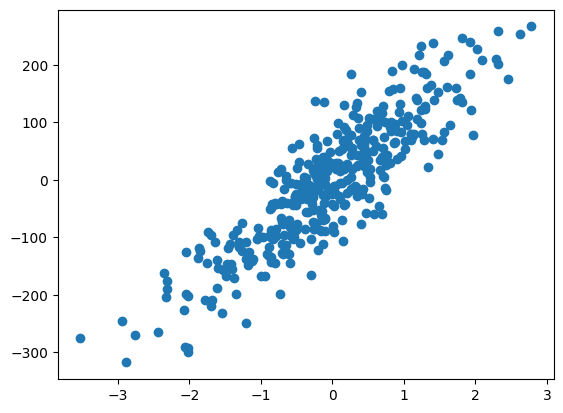

In [ ]:
plt.scatter(x[1], y)

Для построения линии модели просто использовать plot вот так: _plt.plot(x[1], y)_ будет уже неправильно. Лучше построить равномерное распределение точек от минимального до максимального по _X_ и уже по нему расчитать модельные значения:


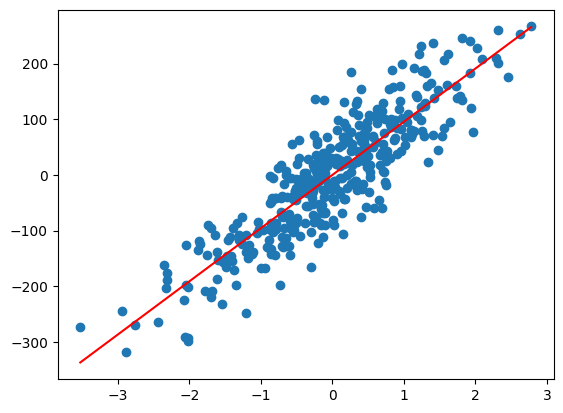

In [ ]:
xx = np.linspace(x[1].min(), x[1].max(), 100).reshape((-1, 1))
plt.plot(xx, binary.predict(xx), c='r')
plt.scatter(x[1], y)

Вот что получится в итоге:

![График регрессии](https://github.com/koroteevmv/ML_course/blob/main/ML1.2%20multivariate/img/ml12-1.png?raw=true)

Для оценки качества построенной регрессии можно использовать целый ряд показателей. Одним из самых простых и универсальных является коэффициент детерминации (R2-score). Как использовать его читайте в [официальной документации sklearn](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html#sklearn.metrics.r2_score). Методом score можно узнать значение метрики эффективности полученной модели:


In [ ]:
binary.score(x[[1]], y)

0.7699743283650629

В нашем случае оценка будет примерно 0.77, что свидетельствует о средней точности модели.

Для построения множественной регрессии выполним те же шаги, но будем использовать полный датасет:


In [ ]:
multiple = LinearRegression()
multiple.fit(x, y)
multiple.score(x, y)

0.9922198026415868

Теперь точность возросла до 0.99, что говорит о почти идеальной модели. Вообще чем больше информации мы подаем на вход моделям машинного обучения, тем на более сильный результат мы можем рассчитывать.

В модели множественной регрессии уже не удасся построить такой красивый и однозначный график. Для того, чтобы хоть как-то увидеть, как модель соотносится с точками, можно построить график зависимости теоретических значений от эмпирических, то есть как предсказанные значения отличаются от истинных:

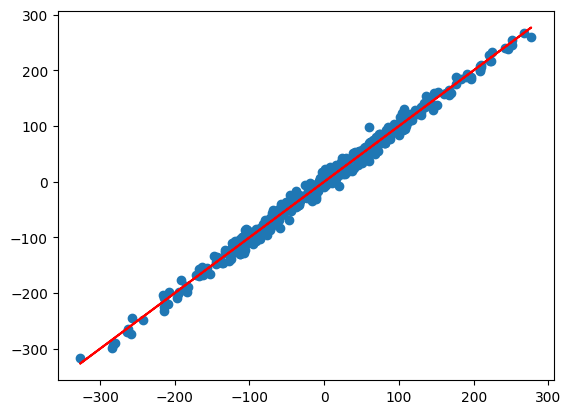

In [ ]:
yy = multiple.predict(x)
plt.scatter(yy, y)
plt.plot(yy, yy, c='r')

Дополнительно на этом графике мы добавили линию _y=y_. Это всегда будет прямая, даже если мы будем использовать нелинейные модели. Обратите внимание, что на данном графике по обоим осям _Y_ - то есть целевая переменная:

![График регрессии](https://github.com/koroteevmv/ML_course/blob/main/ML1.2%20multivariate/img/ml12-2.png?raw=true)

Такой график наряду с диагностическими кривыми можно использовать для диагностики многомерных задач регресии.


#### Задания для самостоятельного выполнения
1. Самостоятельно постройте парные регрессии от каждого атрибута с целевой переменной.
1. Для целевой переменной и каждого из признаков постройте полиномиальную регрессию второго, третьего и десятого порядков. Сделайте вывод о значимости регрессии.
2. Постройте сводную таблицу показателей точности всех построенных моделей. Сделайте вывод, какие модели переобученнные, какие - недообученные.


### Задание 1: Построить парные регрессии от каждого атрибута с целевой переменной.

In [ ]:
from sklearn.linear_model import LinearRegression

# Словарь для хранения R2-score для парных линейных регрессий
pairwise_linear_r2_scores = {}

for i in range(x.shape[1]):
    # Выбираем один признак (столбец) из x
    feature = x[[i]]

    # Создаем и обучаем модель линейной регрессии
    model = LinearRegression()
    model.fit(feature, y)

    # Вычисляем R2-score
    r2 = model.score(feature, y)
    pairwise_linear_r2_scores[f'Признак {i}'] = r2

    print(f"R2-score для признака {i} (x[[{i}]]) и y: {r2:.4f}")

print("\nСводка R2-score для парных линейных регрессий:")
for feature, score in pairwise_linear_r2_scores.items():
    print(f"{feature}: {score:.4f}")

R2-score для признака 0 (x[[0]]) и y: 0.0436
R2-score для признака 1 (x[[1]]) и y: 0.7700
R2-score для признака 2 (x[[2]]) и y: 0.1879
R2-score для признака 3 (x[[3]]) и y: 0.0475
R2-score для признака 4 (x[[4]]) и y: 0.0002

Сводка R2-score для парных линейных регрессий:
Признак 0: 0.0436
Признак 1: 0.7700
Признак 2: 0.1879
Признак 3: 0.0475
Признак 4: 0.0002


### Задание 2: Для целевой переменной и каждого из признаков постройте полиномиальную регрессию второго, третьего и десятого порядков. Сделайте вывод о значимости регрессии.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression

polynomial_degrees = [2, 3, 10]
polynomial_r2_scores = {}

print("Построение полиномиальных регрессий:")
for i in range(x.shape[1]):
    feature_name = f'Признак {i}'
    feature_data = x[[i]]

    print(f"\n-- {feature_name} --")
    for degree in polynomial_degrees:
        # Создаем пайплайн для полиномиальной регрессии
        # Сначала генерируем полиномиальные признаки, затем применяем линейную регрессию
        model = make_pipeline(PolynomialFeatures(degree=degree),
                              LinearRegression())

        # Обучаем модель
        model.fit(feature_data, y)

        # Оцениваем качество модели (R2-score)
        r2 = model.score(feature_data, y)
        polynomial_r2_scores[f'{feature_name} (степень {degree})'] = r2

        print(f"  R2-score для полиномиальной регрессии (степень {degree}): {r2:.4f}")

print("\nСводка R2-score полиномиальных регрессий:")
for model_name, score in polynomial_r2_scores.items():
    print(f"{model_name}: {score:.4f}")

Построение полиномиальных регрессий:

-- Признак 0 --
  R2-score для полиномиальной регрессии (степень 2): 0.0437
  R2-score для полиномиальной регрессии (степень 3): 0.0438
  R2-score для полиномиальной регрессии (степень 10): 0.0504

-- Признак 1 --
  R2-score для полиномиальной регрессии (степень 2): 0.7700
  R2-score для полиномиальной регрессии (степень 3): 0.7711
  R2-score для полиномиальной регрессии (степень 10): 0.7727

-- Признак 2 --
  R2-score для полиномиальной регрессии (степень 2): 0.1900
  R2-score для полиномиальной регрессии (степень 3): 0.1928
  R2-score для полиномиальной регрессии (степень 10): 0.2044

-- Признак 3 --
  R2-score для полиномиальной регрессии (степень 2): 0.0479
  R2-score для полиномиальной регрессии (степень 3): 0.0503
  R2-score для полиномиальной регрессии (степень 10): 0.0727

-- Признак 4 --
  R2-score для полиномиальной регрессии (степень 2): 0.0010
  R2-score для полиномиальной регрессии (степень 3): 0.0011
  R2-score для полиномиальной регр

### Задание 3: Построить сводную таблицу показателей точности всех построенных моделей. Сделайте вывод, какие модели переобученные, какие - недообученные.

In [ ]:
import pandas as pd

# Объединяем все R2-score в один словарь
all_r2_scores = {}
all_r2_scores.update(pairwise_linear_r2_scores)
all_r2_scores.update(polynomial_r2_scores)

# Преобразуем словарь в DataFrame Pandas для лучшей визуализации
r2_df = pd.DataFrame(all_r2_scores.items(), columns=['Модель', 'R2-score'])
r2_df['R2-score'] = r2_df['R2-score'].round(4) # Округляем для лучшей читаемости
r2_df = r2_df.sort_values(by='R2-score', ascending=False).reset_index(drop=True)

print("\nСводная таблица R2-score для всех моделей:")
display(r2_df)




Сводная таблица R2-score для всех моделей:


,Модель,R2-score
0,Признак 1 (степень 10),0.7727
1,Признак 1 (степень 3),0.7711
2,Признак 1,0.7700
3,Признак 1 (степень 2),0.7700
4,Признак 2 (степень 10),0.2044
5,Признак 2 (степень 3),0.1928
6,Признак 2 (степень 2),0.1900
7,Признак 2,0.1879
8,Признак 3 (степень 10),0.0727
9,Признак 0 (степень 10),0.0504


Выводы о значимости регрессии, переобучении и недообучении:
На основе сводной таблицы R2-score можно сделать следующие выводы:
1. **Наиболее значимые признаки (Признак 1):** Линейная и полиномиальные регрессии для Признака 1 показывают самые высокие R2-score среди всех парных моделей (около 0.77). Это говорит о том, что Признак 1 имеет сильную линейную связь с целевой переменной. Увеличение степени полинома для Признака 1 лишь незначительно повышает R2-score, что указывает на то, что линейная модель уже хорошо описывает эту связь, и дальнейшее усложнение не дает существенных преимуществ.
2. **Менее значимые признаки (Признак 0, 2, 3, 4):** Для остальных признаков (0, 2, 3, 4) R2-score значительно ниже, как для линейных, так и для полиномиальных моделей низких порядков (2 и 3). Это означает, что эти признаки по отдельности имеют слабую линейную или нелинейную связь с целевой переменной.
   - Для Признака 4 R2-score крайне низкий даже для полинома 10-го порядка (0.0451), что указывает на его очень низкую значимость.
3. **Потенциальное недообучение:** Модели с очень низким R2-score (например, Признак 0, 3, 4) являются недообученными (underfitted). Они не улавливают закономерности в данных, так как признаки, вероятно, не являются сильными предикторами для целевой переменной по отдельности, или же требуется более сложная модель, учитывающая их взаимодействие.
4. **Признаки переобучения:**
   - Увеличение степени полинома с 2 до 10 для большинства признаков (особенно для Признак 0, 2, 3, 4) приводит к увеличению R2-score на тренировочных данных. Однако, учитывая низкие абсолютные значения R2-score, это увеличение, является индикатором **переобучения (overfitting)** на шумовых данных или специфических паттернах тренировочного набора. Для более точного определения переобучения необходимо использовать данные для валидации и тестирования.

**Общий вывод:** Парные модели, как линейные, так и полиномиальные, показывают разную степень связи с целевой переменной. Признак 1 является наиболее значимым. Для более точных выводов о переобучении и недообучении, а также о реальной предсказательной способности моделей, необходимо использовать независимые тестовые данные и применять методы кросс-валидации.